In [1]:
import os
import re

import numpy as np
import pandas as pd

In [2]:
def chemical_formula_sort(formulas):
    def get_sort_key(formula):
        counts = [int(n) if n else 1 for _, n in re.findall(r'([A-Z])(\d*)', formula)]

        total_atoms = sum(counts)

        distribution = [-c for c in sorted(counts, reverse=True)]
        
        return (total_atoms, distribution)

    return sorted(formulas, key=get_sort_key)

In [3]:
def format_formula_for_matplotlib(formula):
    """
    Converts a chemical formula string like 'A3B2C' into a 
    Matplotlib-renderable LaTeX string like '$A_{3}B_{2}C$'.
    """
    # Find all letter groups followed by optional number groups
    parts = re.findall(r'([A-Z]+)(\d*)', formula)
    
    # Build the formatted string
    latex_string = ""
    for letter, number in parts:
        latex_string += letter
        if number:
            # If a number exists, wrap it in '_{...}' for subscript
            latex_string += f'_{{{number}}}'
            
    # Wrap the entire result in '$' to enable math text rendering
    return r"$\mathrm{" + latex_string + r"}$"


In [4]:
df = pd.read_csv("MOLPIPx-set-bench-linear.csv")

df

,system,order,num_pips,num_flat_exponents,jit,run
0,A2B,3,13,20,1.002868,0.000111
1,A2B,4,22,35,1.021084,0.000114
2,A2B,5,34,56,0.991995,0.000137
3,A2B,6,50,84,1.002803,0.000136
4,A2B,7,70,120,1.020859,0.000140
...,...,...,...,...,...,...
79,ABCDE,4,1001,1001,1.153768,0.000151
80,ABCDE,5,3003,3003,1.177339,0.000187
81,ABCDE,6,8008,8008,1.203272,0.000282
82,ABCDE,7,19448,19448,1.306431,0.000467


In [5]:
import scienceplots

from matplotlib import pyplot as plt

In [6]:
def plot_bench(
    df: pd.DataFrame,
    col_name: str,
    system_order=None,
) -> None:
    if not system_order:
        unique_systems = list(set(df["system"].values.tolist()))
        system_order = chemical_formula_sort(unique_systems)

    system_to_idx = {name: i for i, name in enumerate(system_order)}

    with plt.style.context(["science", "no-latex"]):
        fig = plt.figure(figsize=(5, 4), dpi=600)
        ax = fig.add_subplot(111)

        orders = sorted(df['order'].unique())
        colors = plt.cm.viridis_r(np.linspace(0, 1, len(orders)))

        for i, order in enumerate(orders):
            subset = df[df['order'] == order].copy()
            subset['x_idx'] = subset['system'].map(system_to_idx)
            subset = subset.sort_values('x_idx')

            ax.plot(
                subset['x_idx'], 
                subset[col_name], 
                marker='s',
                label=f'{order}',
                color=colors[i],
                markersize=5,
                linewidth=1.2
            )


        ax.set_xticks(range(len(system_order)))

        formatted_labels = [format_formula_for_matplotlib(s) for s in system_order]
        ax.set_xticklabels(formatted_labels, rotation=90)

        ax.minorticks_off()
        ax.set_yscale('log')
        
        ax.legend(ncol=1, frameon=False)
        # ax.set_ylabel("JIT Time (s)" if col_name == "jit")

        if col_name.lower() == "jit":
            ax.set_ylabel("JIT Time (s)")
        elif col_name.lower() == "run":
            ax.set_ylabel("Run Time (s)")
        elif col_name.lower() == "num_pips":
            ax.set_ylabel(r"$N_\mathrm{poly}$")
        elif col_name.lower() == "num_flat_exponents":
            ax.set_ylabel(r"$N_\mathrm{flat \; exp}$")

        ax.set_xlabel("System")

        ax.grid(True, which="both", ls="--", alpha=0.3)

        plt.tight_layout()
        plt.show()

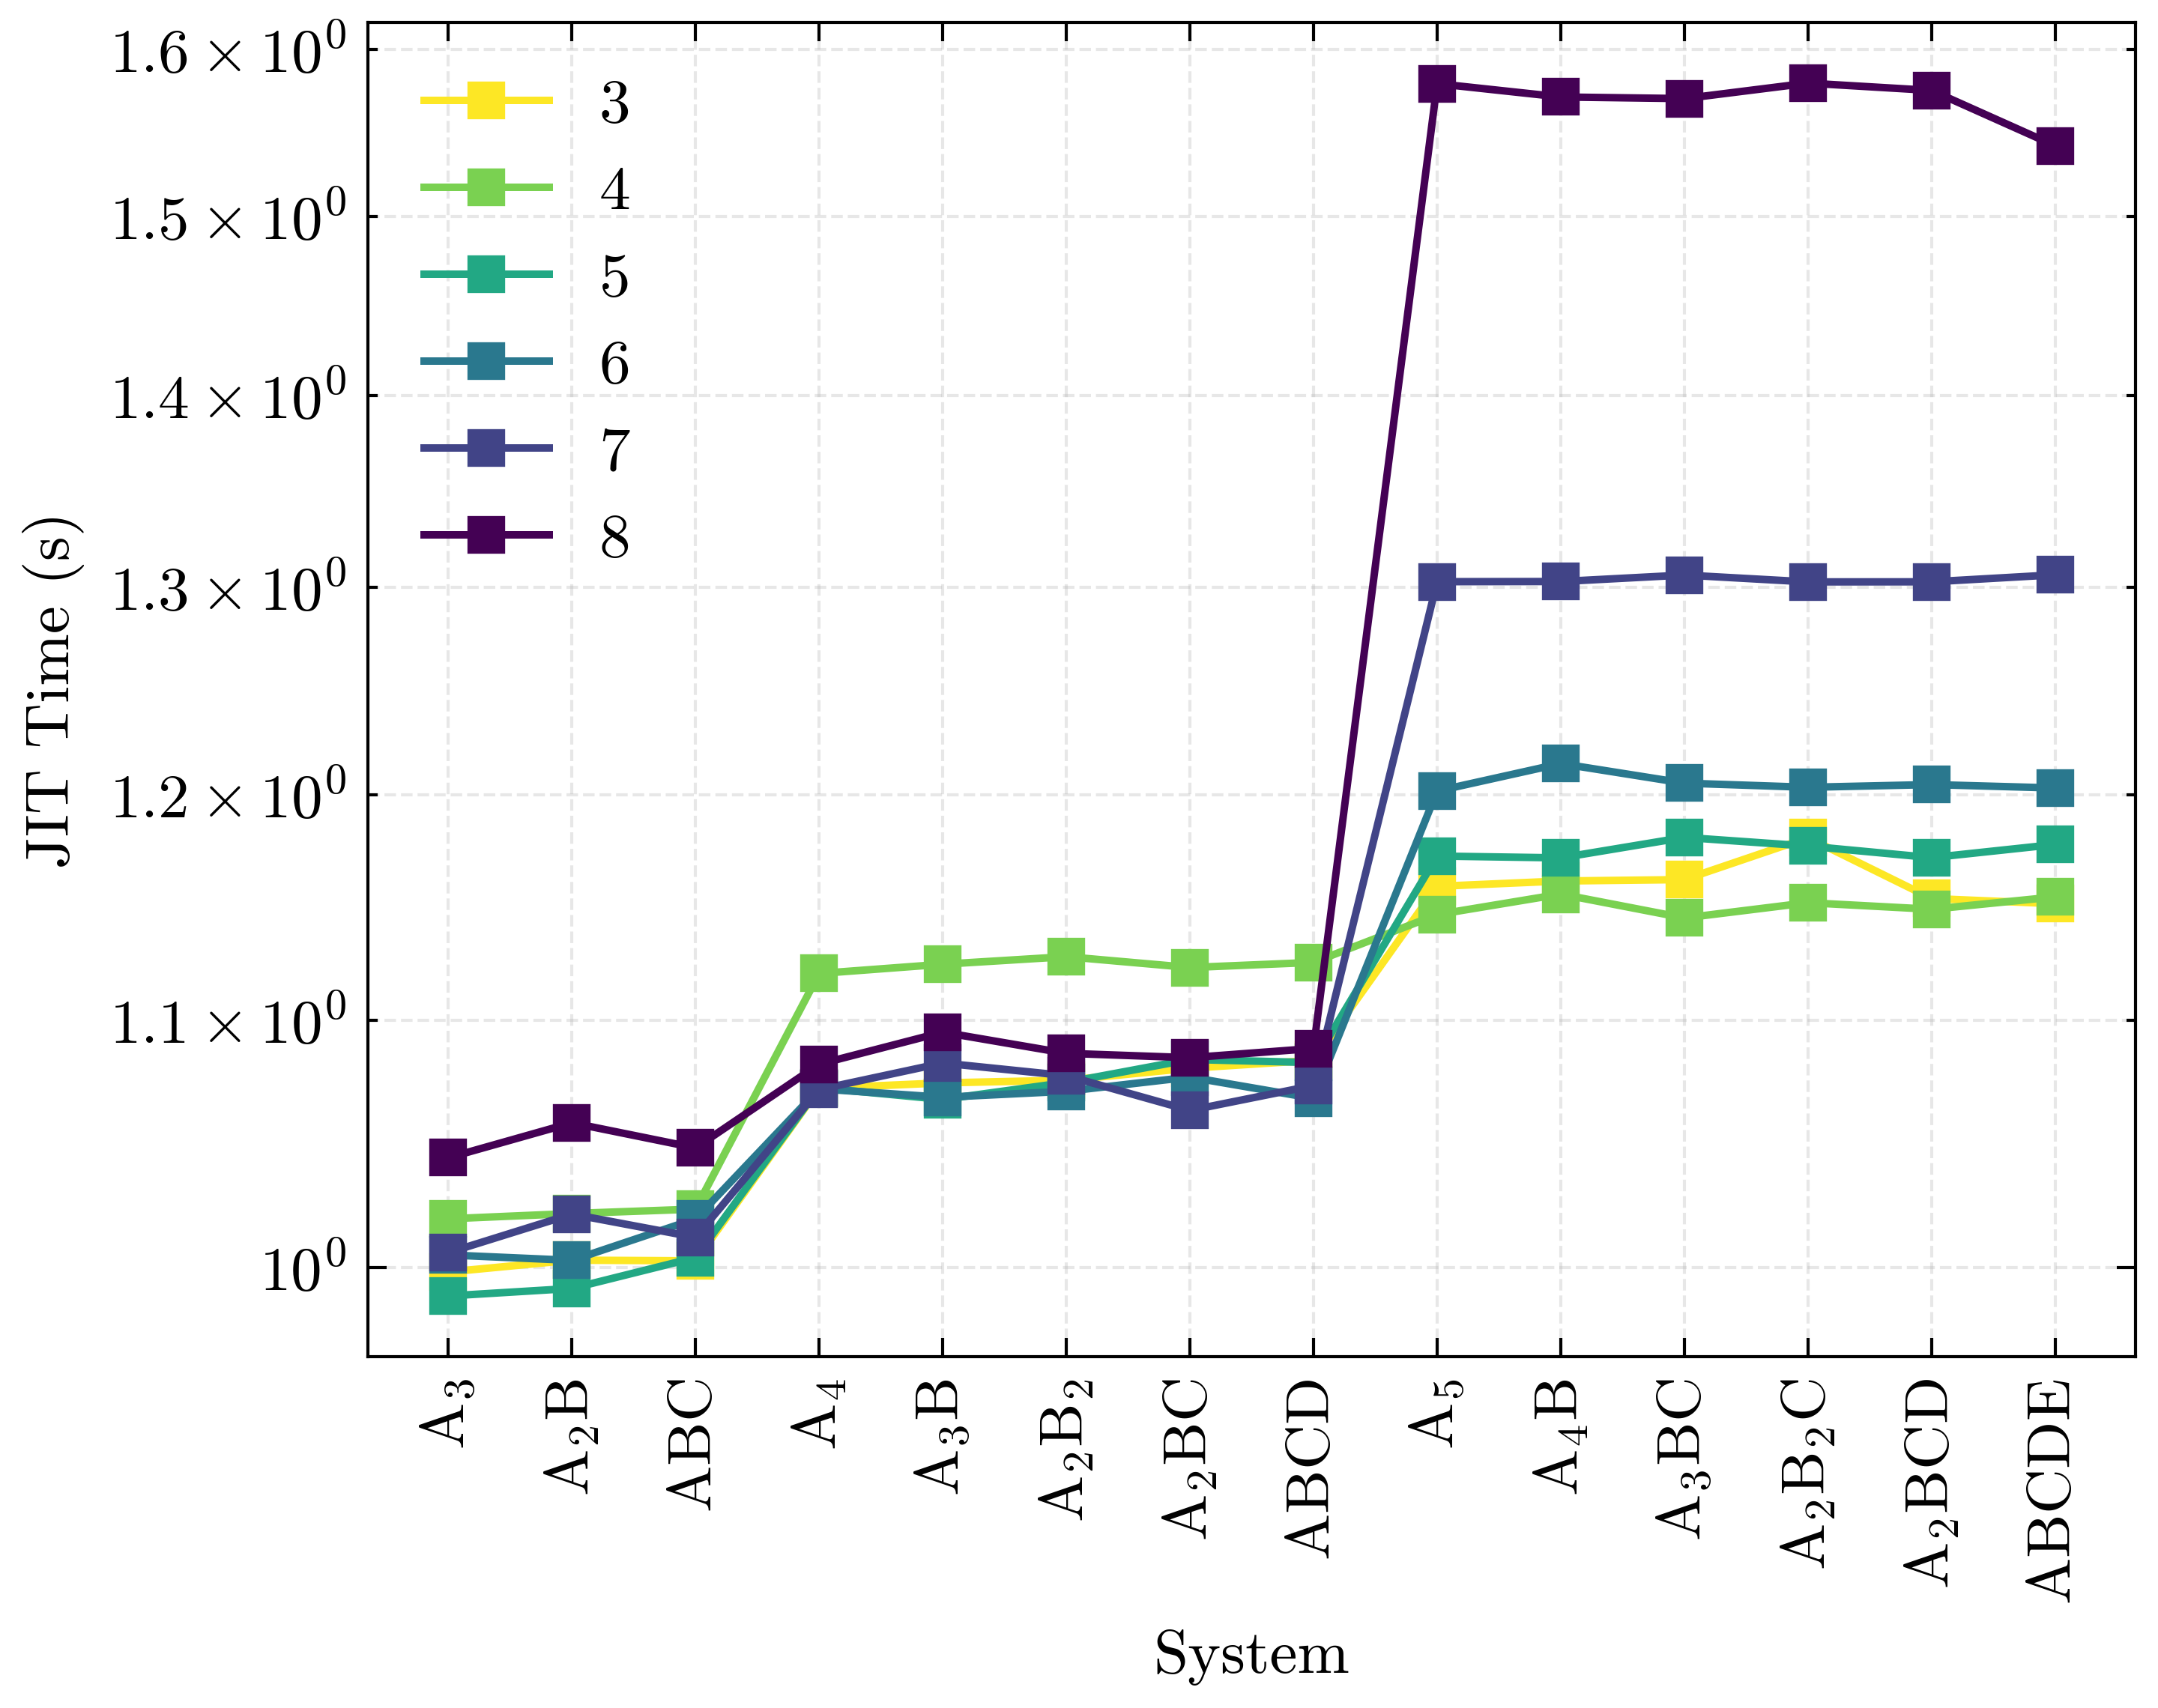

In [7]:
%matplotlib inline

plot_bench(df, "jit")

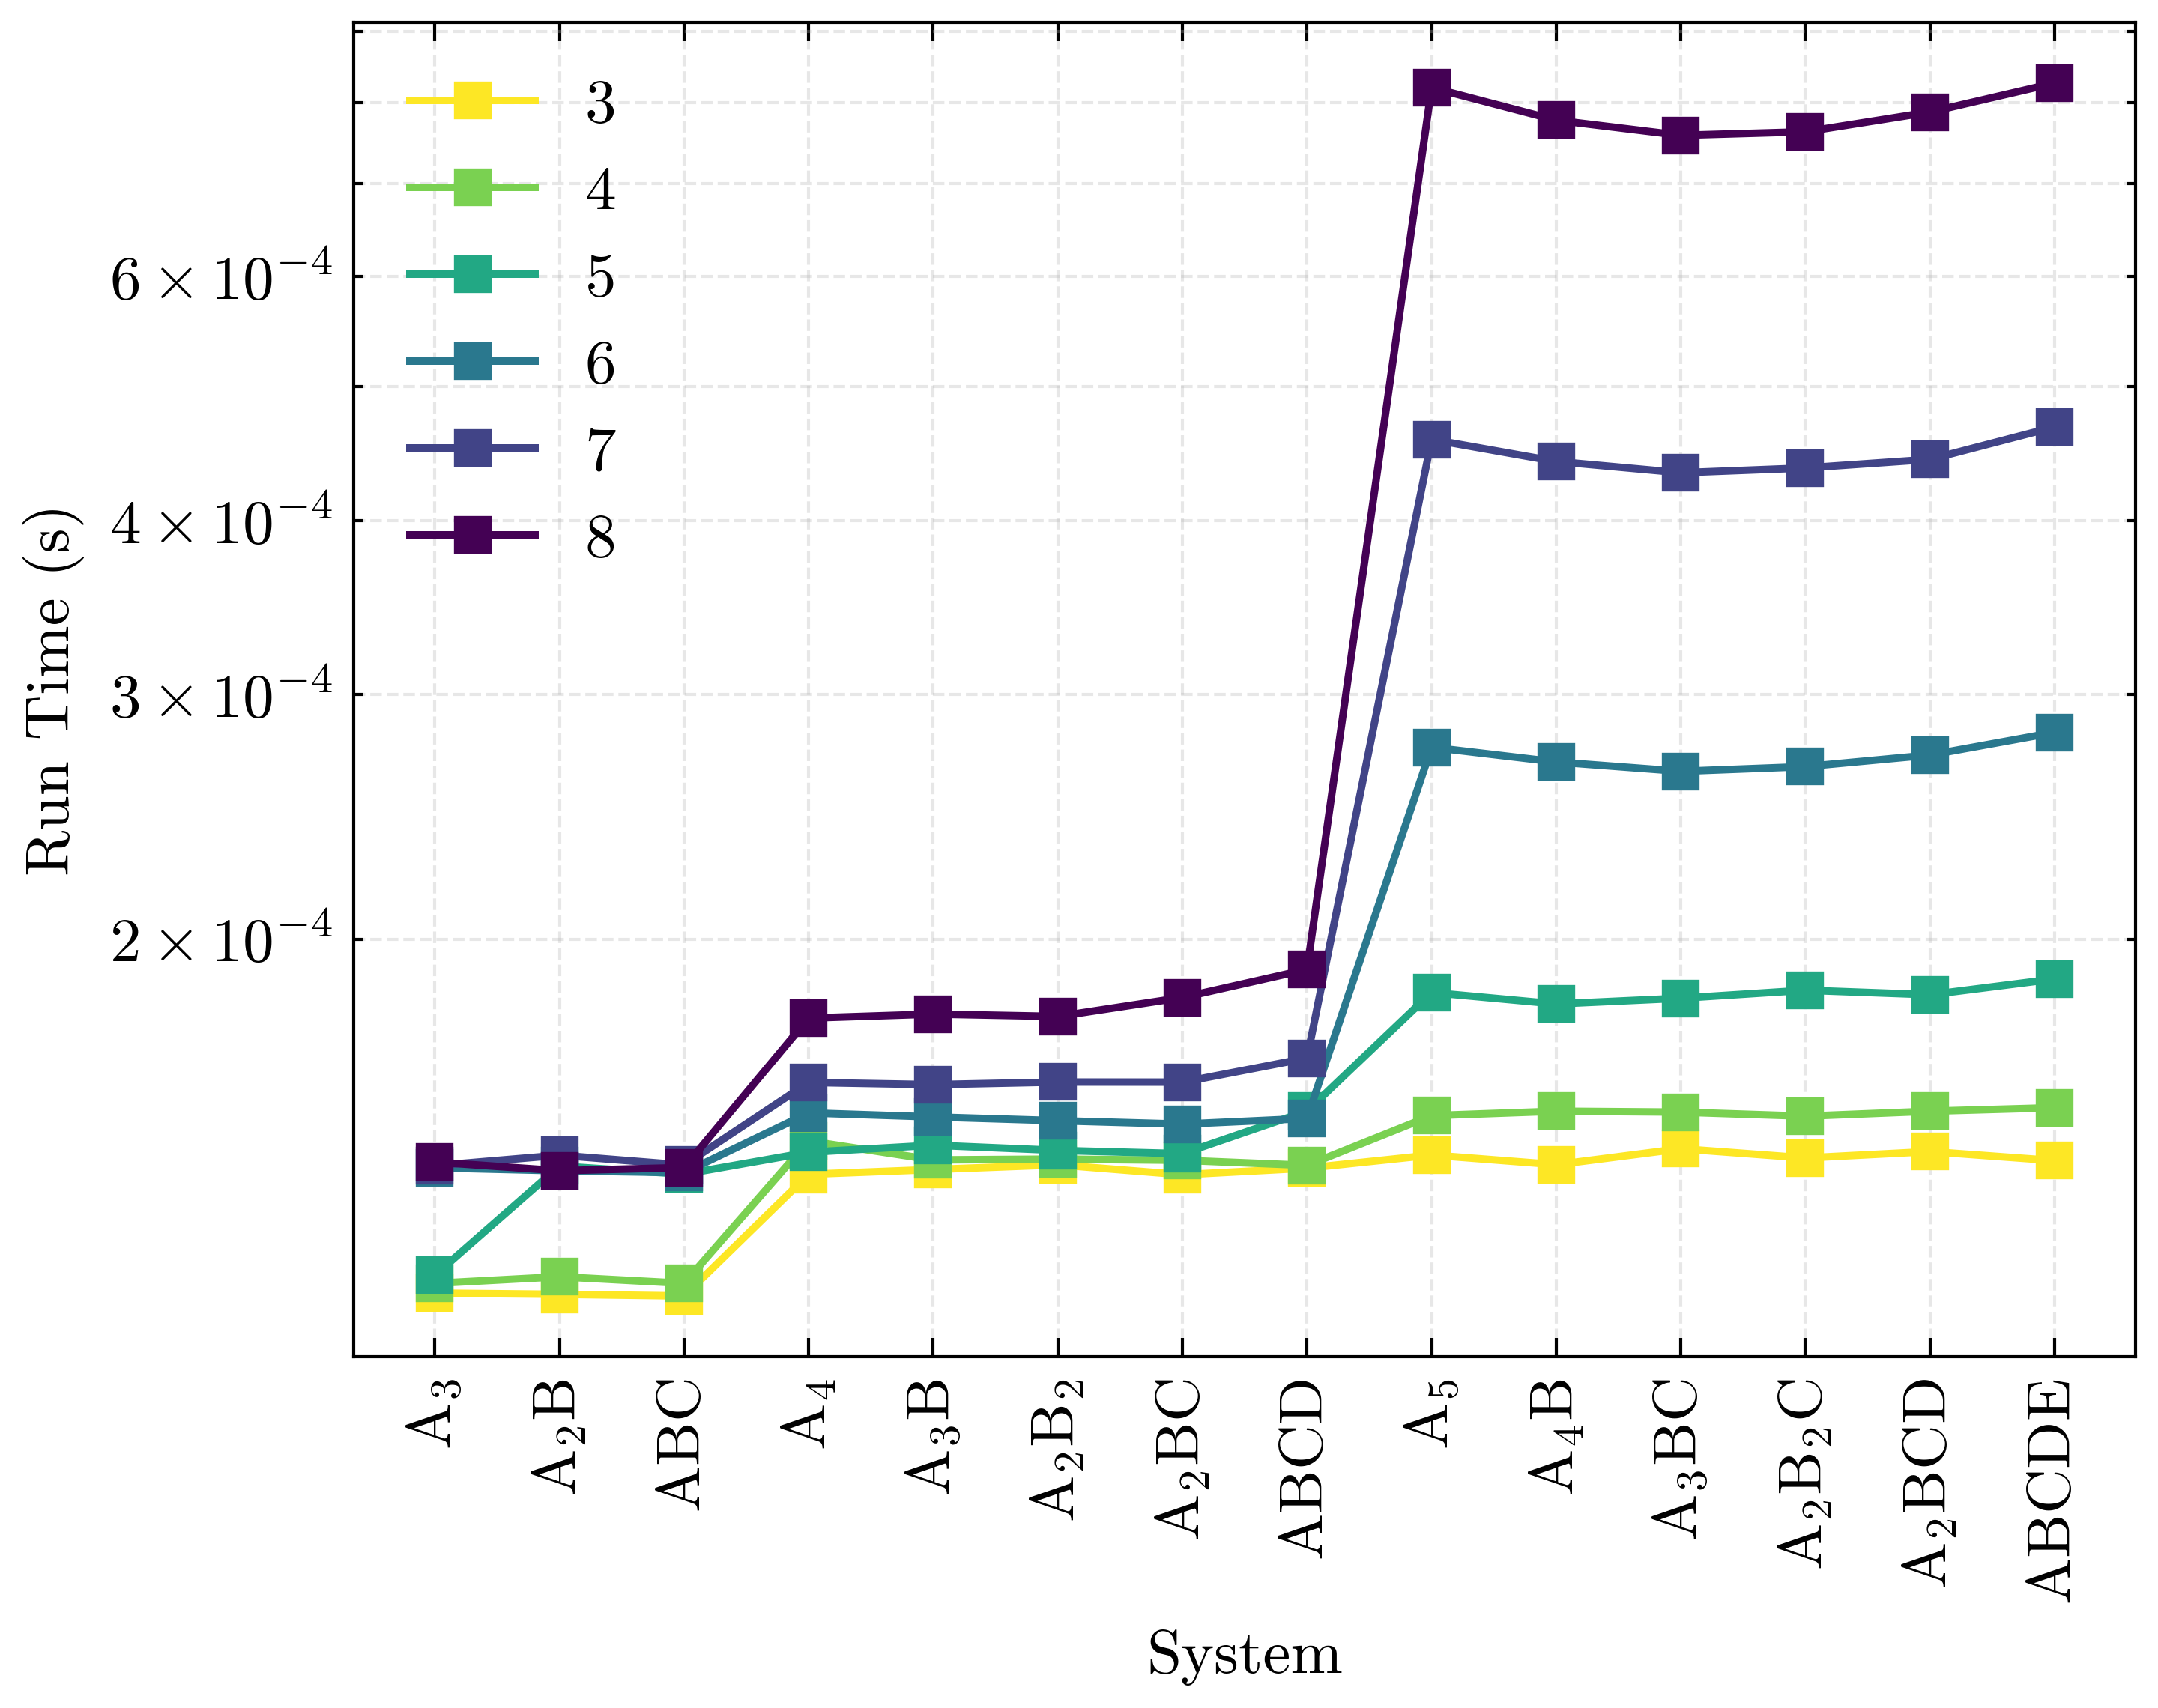

In [8]:
%matplotlib inline

plot_bench(df, "run")

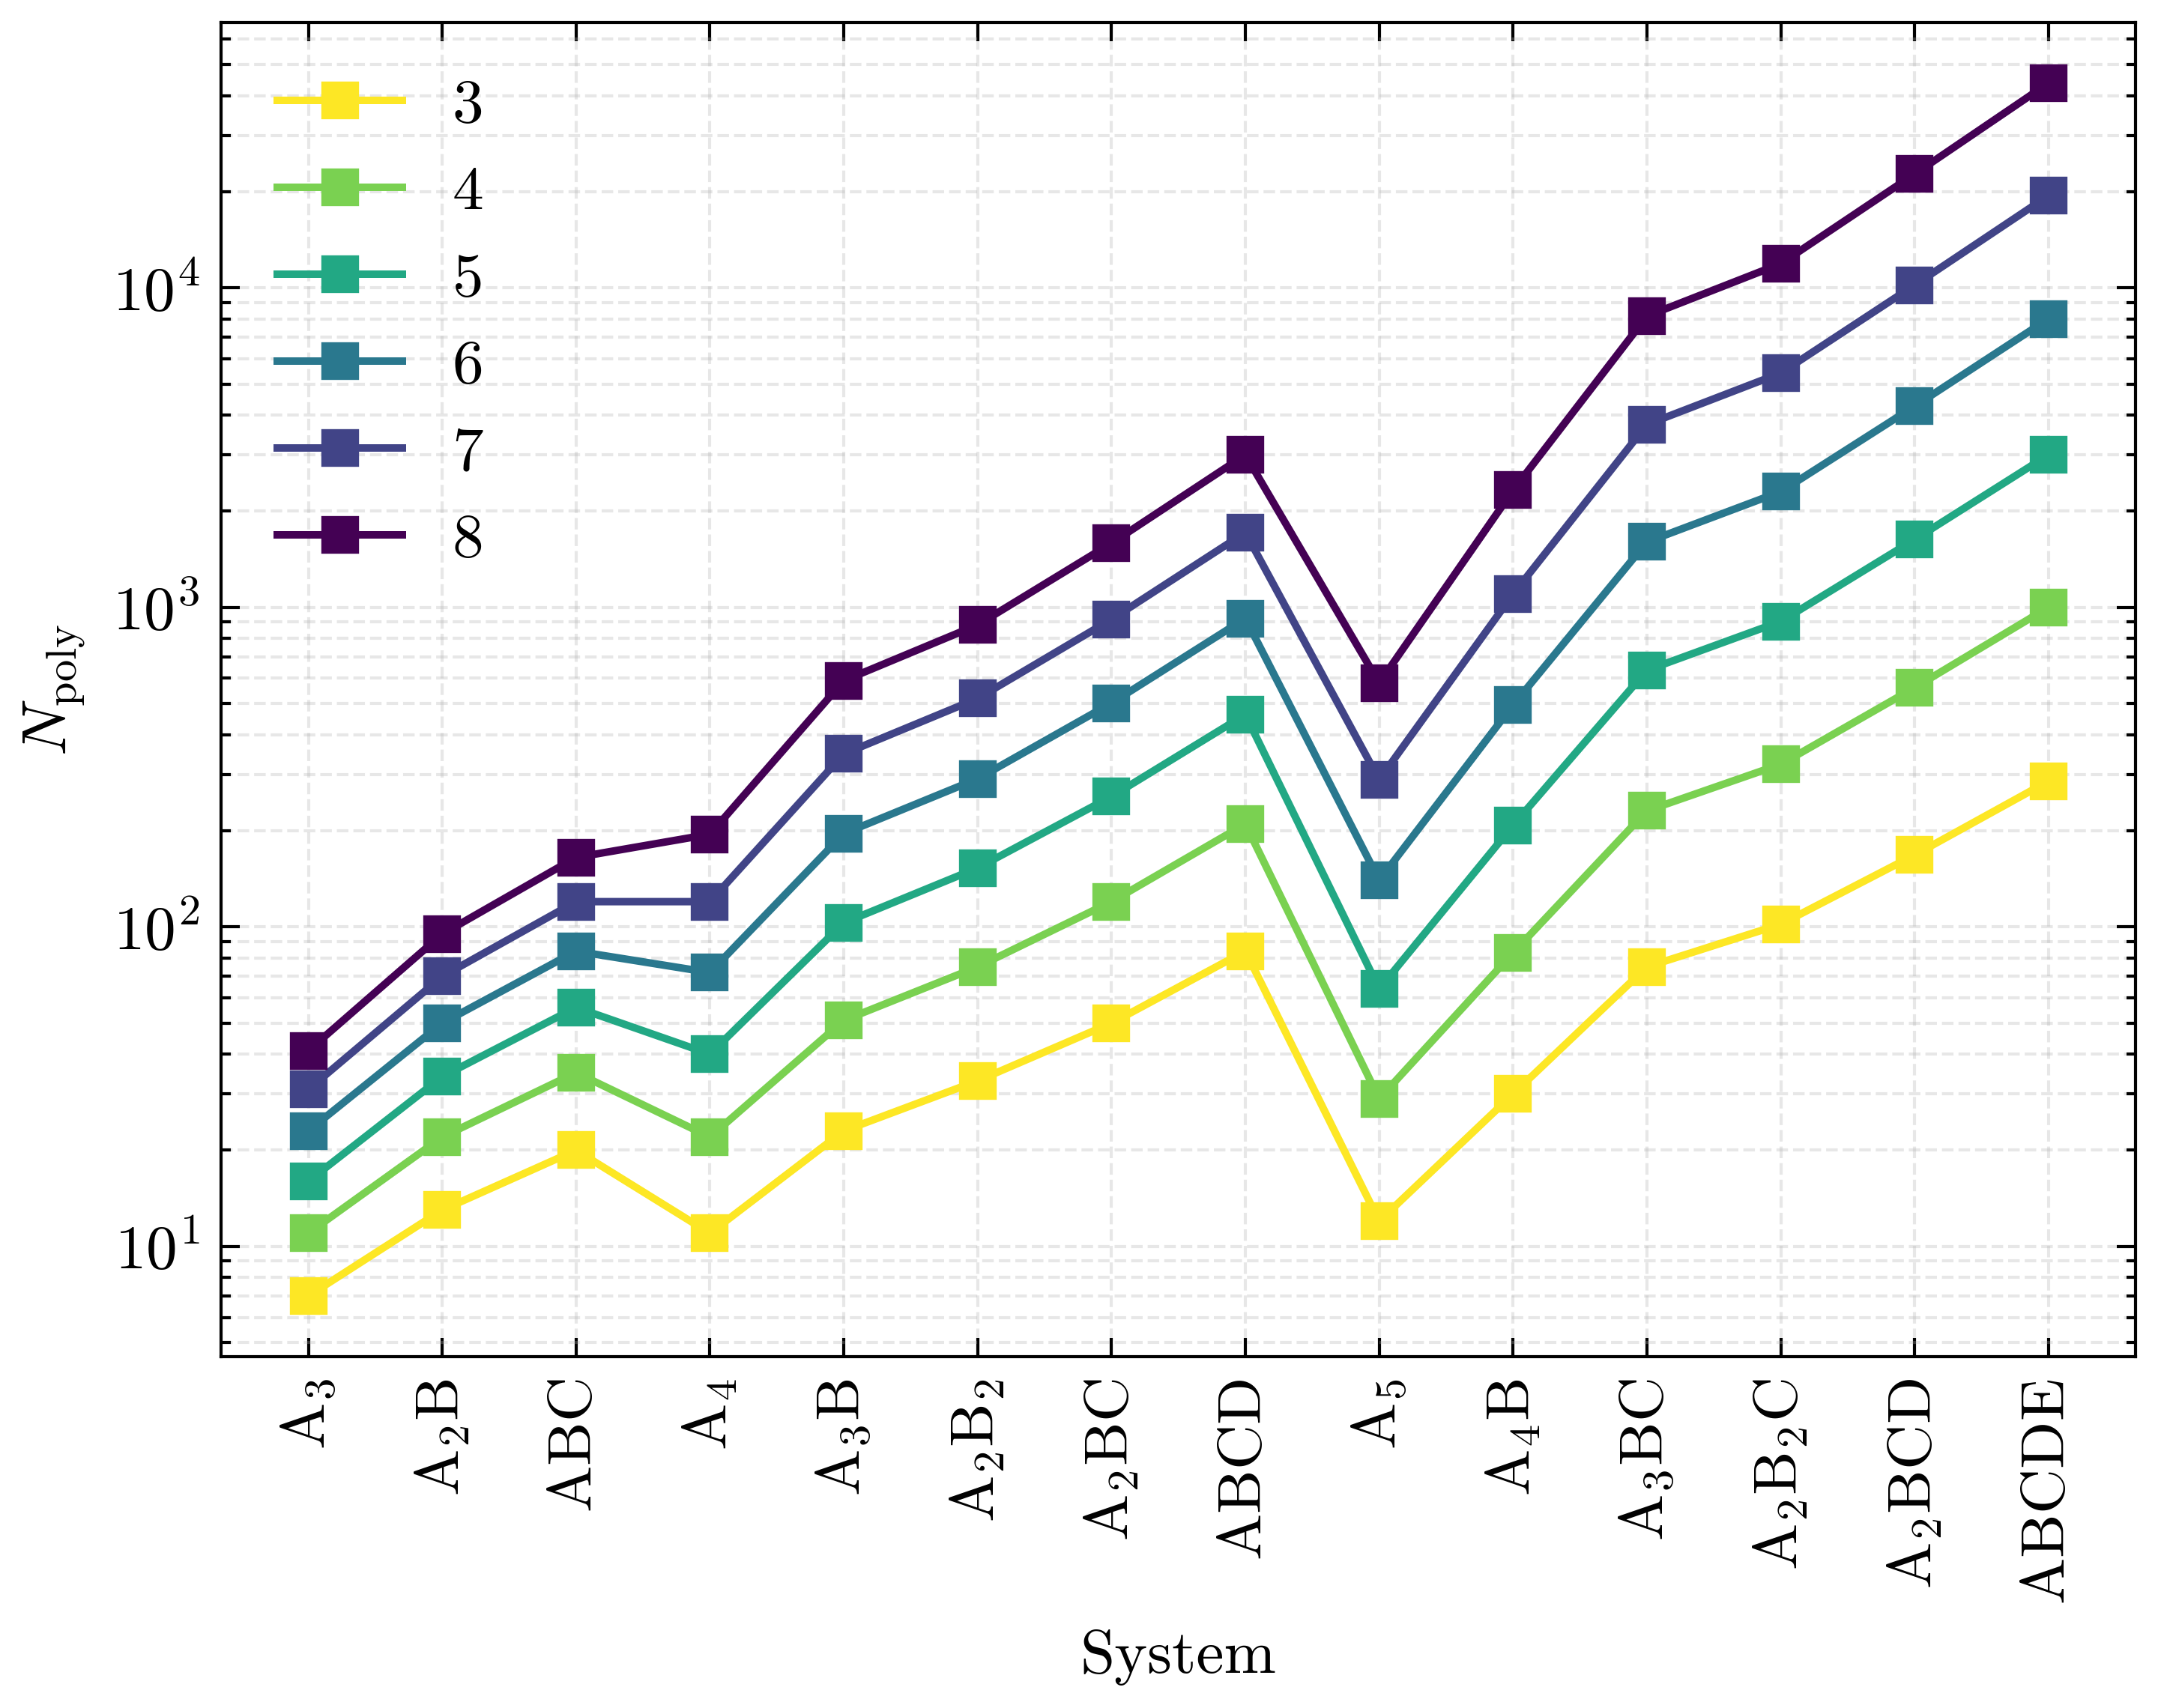

In [9]:
%matplotlib inline

plot_bench(df, "num_pips")

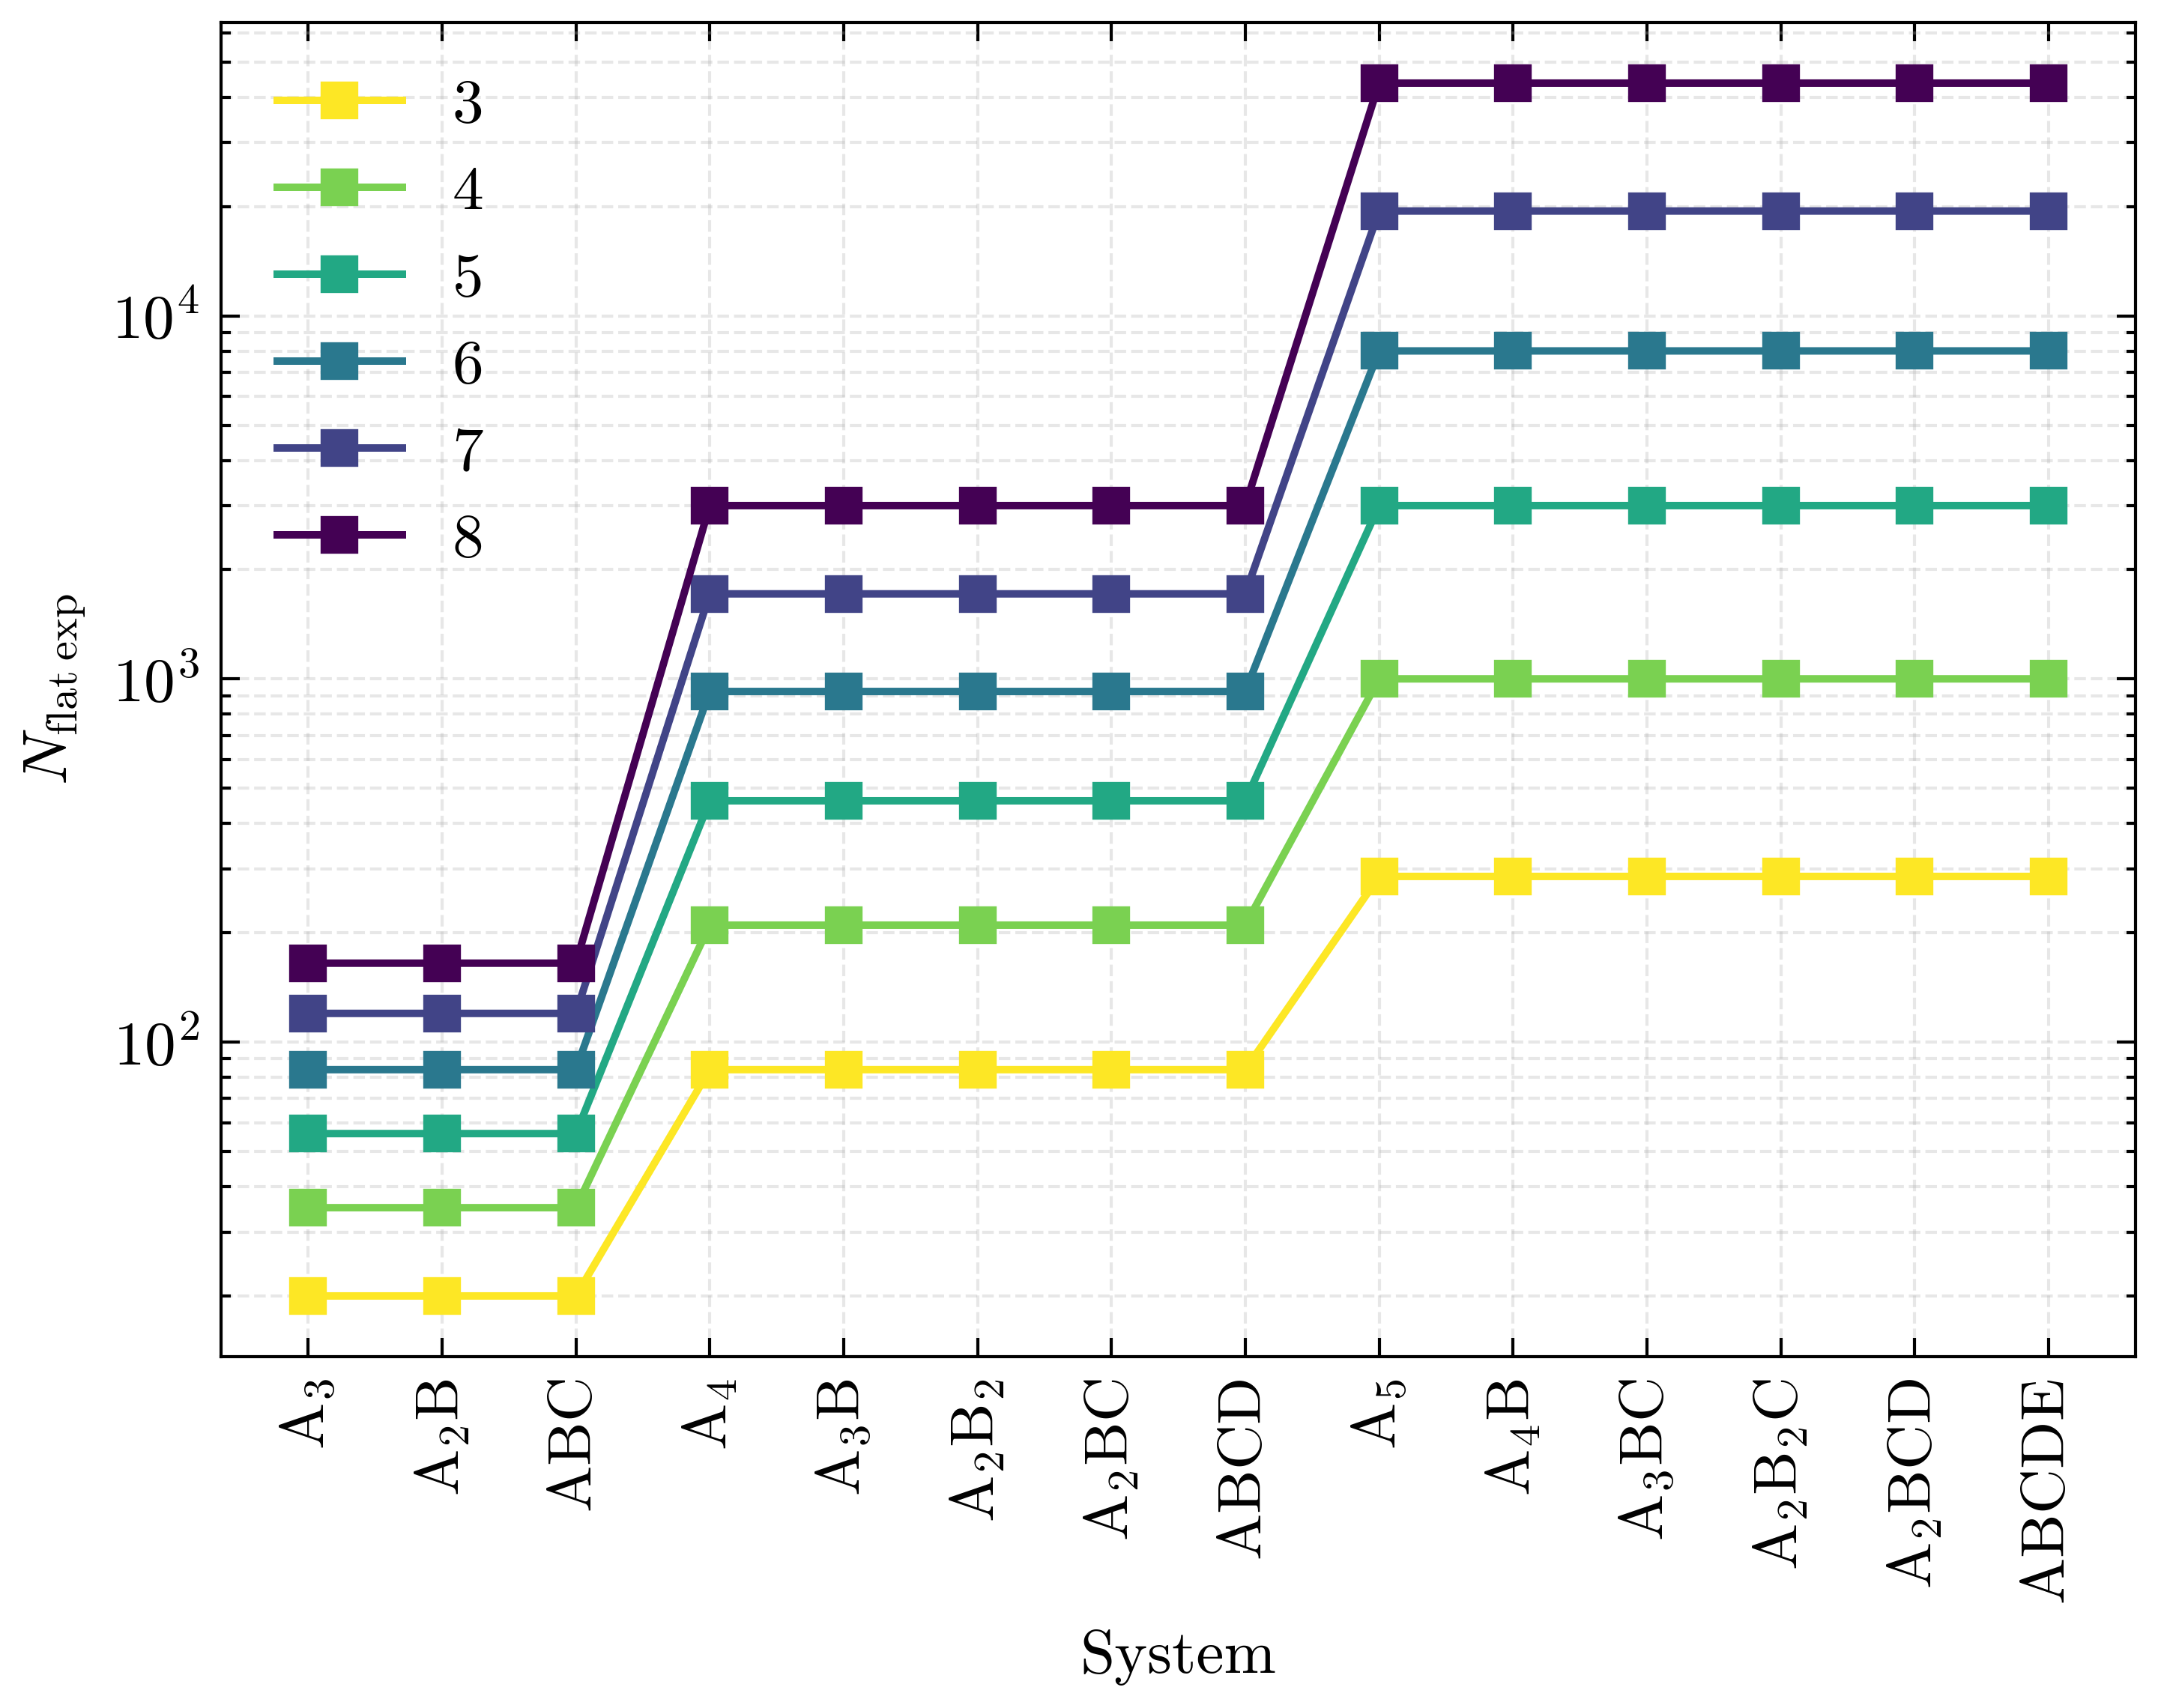

In [10]:
%matplotlib inline

plot_bench(df, "num_flat_exponents")